Computing k-points: 100%|██████████| 10000/10000 [4:01:58<00:00,  1.45s/it]     


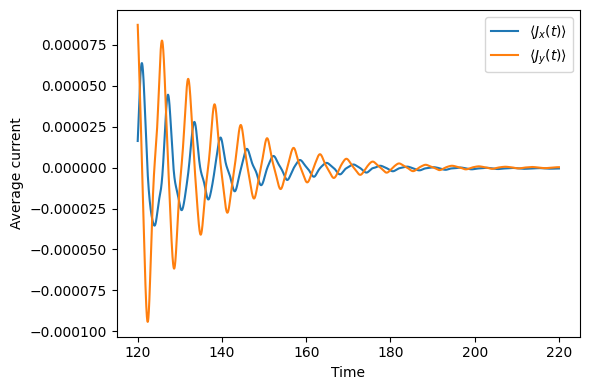

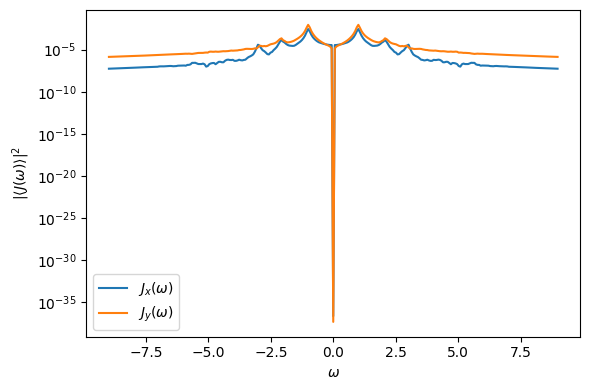

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from tqdm import tqdm

# parameters
Nk = 100
Delta = 1.0
A0 = 0.6
omega = 1.0
T = 2 * np.pi / omega

t_final = 220.0
Nt = 26400
t_eval = np.linspace(0, t_final, Nt)

gamma = 0.03
eta = 0.08

# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

# Hamiltonian
def h_vec(kx, ky):
    return np.array([
        np.sin(kx),
        np.sin(ky),
        Delta + np.cos(kx) + np.cos(ky)
    ])

def H(kx, ky):
    hx, hy, hz = h_vec(kx, ky)
    return hx * sx + hy * sy + hz * sz

def H_t(t, kx, ky):
    return H(kx + A0 * np.sin(omega * t), ky)

# current operators
def jx(t, kx):
    return (
        np.cos(kx + A0 * np.sin(omega * t)) * sx
        - np.sin(kx + A0 * np.sin(omega * t)) * sz
    )

def jy(ky):
    return np.cos(ky) * sy - np.sin(ky) * sz

# Schrödinger equation
def schrodinger_band(t, psi, kx, ky, U):
    H_band = U.conj().T @ H_t(t, kx, ky) @ U
    return -1j * H_band @ psi - gamma * psi

# k-grid
kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

Jx_t = np.zeros(Nt)
Jy_t = np.zeros(Nt)

total_k = Nk * Nk

# main loop
with tqdm(total=total_k, desc="Computing k-points") as pbar:
    for kx in kvals:
        for ky in kvals:

            H0 = H(kx, ky)
            evals, U = np.linalg.eigh(H0)

            psi0 = np.array([0.0, 1.0], dtype=complex)

            sol = solve_ivp(
                schrodinger_band,
                (0, t_final),
                psi0,
                t_eval=t_eval,
                args=(kx, ky, U),
                rtol=1e-7,
                atol=1e-9,
            )

            psi_t = sol.y.T

            norms = np.linalg.norm(psi_t, axis=1, keepdims=True)
            psi_t = psi_t * (1 + eta * (1 - norms))

            for i, (t, psi) in enumerate(zip(t_eval, psi_t)):

                jx_band = U.conj().T @ jx(t, kx) @ U
                jy_band = U.conj().T @ jy(ky) @ U

                Jx_t[i] += np.real(np.vdot(psi, jx_band @ psi))
                Jy_t[i] += np.real(np.vdot(psi, jy_band @ psi))

            pbar.update(1)

# Brillouin zone average
Jx_t /= Nk**2
Jy_t /= Nk**2

mask = (t_eval >= 120) & (t_eval <= 220)

t_window = t_eval[mask]
Jx_window = Jx_t[mask]
Jy_window = Jy_t[mask]


Jx_window = Jx_window - np.mean(Jx_window)
Jy_window = Jy_window - np.mean(Jy_window)

plt.figure(figsize=(6,4))
plt.plot(t_window, Jx_window, label=r'$\langle J_x(t)\rangle$')
plt.plot(t_window, Jy_window, label=r'$\langle J_y(t)\rangle$')
plt.xlabel("Time")
plt.ylabel("Average current")
plt.legend()
plt.tight_layout()
plt.show()

dt = t_window[1] - t_window[0]

freqs = fftshift(fftfreq(len(t_window), dt)) * 2*np.pi

Jx_fft_signal = Jx_window
Jy_fft_signal = Jy_window

Jx_fft = fftshift(np.abs(fft(Jx_fft_signal))**2)
Jy_fft = fftshift(np.abs(fft(Jy_fft_signal))**2)

freq_mask = np.abs(freqs) <= 9

plt.figure(figsize=(6,4))
plt.semilogy(freqs[freq_mask], Jx_fft[freq_mask], label=r'$J_x(\omega)$')
plt.semilogy(freqs[freq_mask], Jy_fft[freq_mask], label=r'$J_y(\omega)$')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|\langle J(\omega)\rangle|^2$')
plt.legend()
plt.tight_layout()
plt.show()


tail_mask = (t_eval >= 180) & (t_eval <= 220)

t_tail = t_eval[tail_mask]
Jx_tail = Jx_t[tail_mask] - np.mean(Jx_t[tail_mask])
Jy_tail = Jy_t[tail_mask] - np.mean(Jy_t[tail_mask])

plt.figure(figsize=(6,4))
plt.plot(t_tail, Jx_tail, label=r'$\langle J_x(t)\rangle$')
plt.plot(t_tail, Jy_tail, label=r'$\langle J_y(t)\rangle$')
plt.xlabel("Time")
plt.ylabel("Average current")
plt.title("Late-time current (zoomed tail)")
plt.legend()
plt.tight_layout()
plt.show()

Computing k-points: 100%|██████████| 10000/10000 [2:44:27<00:00,  1.01it/s] 


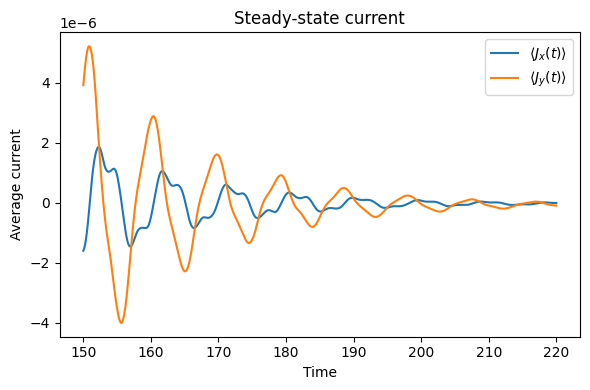

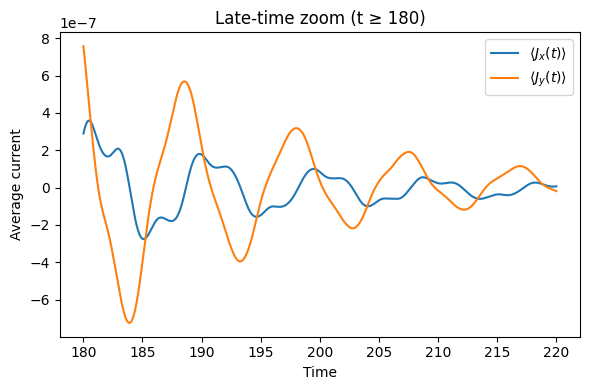

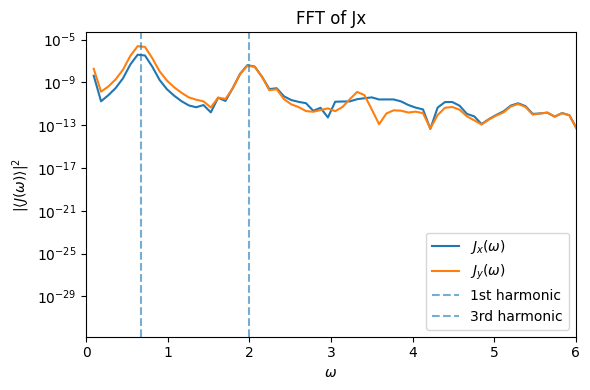

Max |Jy|: 5.2106653487161376e-06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from tqdm import tqdm

Nk = 100
Delta = 1.0
A0 = 0.3          
omega = 2/3    
T = 2 * np.pi / omega

t_final = 220.0
Nt = 26400
t_eval = np.linspace(0, t_final, Nt)

gamma = 0.03
eta = 0.08

#Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

#hamiltonian 
def h_vec(kx, ky):
    return np.array([np.sin(kx), np.sin(ky), Delta + np.cos(kx) + np.cos(ky)])

def H(kx, ky):
    hx, hy, hz = h_vec(kx, ky)
    return hx*sx + hy*sy + hz*sz

def H_t(t, kx, ky):
    return H(kx + A0*np.sin(omega*t), ky)

#current operators 
def jx(t, kx):
    return np.cos(kx + A0*np.sin(omega*t))*sx - np.sin(kx + A0*np.sin(omega*t))*sz

def jy(ky):
    return np.cos(ky)*sy - np.sin(ky)*sz

#Schrodinger eq 
def schrodinger_band(t, psi, kx, ky, U):
    H_band = U.conj().T @ H_t(t, kx, ky) @ U
    return -1j * H_band @ psi - gamma*psi

#k-grid 
kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
Jx_t = np.zeros(Nt)
Jy_t = np.zeros(Nt)

#main loop 
with tqdm(total=Nk*Nk, desc="Computing k-points") as pbar:
    for kx in kvals:
        for ky in kvals:
            H0 = H(kx, ky)
            evals, U = np.linalg.eigh(H0)
            psi0 = np.array([0.0, 1.0], dtype=complex)

            sol = solve_ivp(
                schrodinger_band,
                (0, t_final),
                psi0,
                t_eval=t_eval,
                args=(kx, ky, U),
                rtol=1e-7,
                atol=1e-9
            )

            psi_t = sol.y.T
            norms = np.linalg.norm(psi_t, axis=1, keepdims=True)
            psi_t = psi_t * (1 + eta*(1 - norms))

            for i, (t, psi) in enumerate(zip(t_eval, psi_t)):
                jx_band = U.conj().T @ jx(t, kx) @ U
                jy_band = U.conj().T @ jy(ky) @ U
                Jx_t[i] += np.real(np.vdot(psi, jx_band @ psi))
                Jy_t[i] += np.real(np.vdot(psi, jy_band @ psi))

            pbar.update(1)

#BZ average 
Jx_t /= Nk**2
Jy_t /= Nk**2

#Time windows 
#steady-state for FFT 
mask = (t_eval >= 150) & (t_eval <= 220)
t_window = t_eval[mask]
Jx_window = Jx_t[mask] - np.mean(Jx_t[mask])
Jy_window = Jy_t[mask] - np.mean(Jy_t[mask])

#(t >= 180)
tail_mask = (t_eval >= 180) & (t_eval <= 220)
t_tail = t_eval[tail_mask]
Jx_tail = Jx_t[tail_mask] - np.mean(Jx_t[tail_mask])
Jy_tail = Jy_t[tail_mask] - np.mean(Jy_t[tail_mask])

#Plot time series 
plt.figure(figsize=(6,4))
plt.plot(t_window, Jx_window, label=r'$\langle J_x(t)\rangle$')
plt.plot(t_window, Jy_window, label=r'$\langle J_y(t)\rangle$')
plt.xlabel("Time")
plt.ylabel("Average current")
plt.title("Steady-state current")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(t_tail, Jx_tail, label=r'$\langle J_x(t)\rangle$')
plt.plot(t_tail, Jy_tail, label=r'$\langle J_y(t)\rangle$')
plt.xlabel("Time")
plt.ylabel("Average current")
plt.title("Late-time zoom (t ≥ 180)")
plt.legend()
plt.tight_layout()
plt.show()

#FFT 
dt = t_window[1] - t_window[0]
freqs = fftshift(fftfreq(len(t_window), dt)) * 2*np.pi

#Hanning window 
window = np.hanning(len(Jx_window))
Jx_fft_signal = Jx_window * window
Jy_fft_signal = Jy_window * window

Jx_fft = fftshift(np.abs(fft(Jx_fft_signal))**2)
Jy_fft = fftshift(np.abs(fft(Jy_fft_signal))**2)

#positive frequencies only (remove near-zero)
eps = 1e-6
pos_mask = freqs > eps
freqs_pos = freqs[pos_mask]
Jx_fft_pos = Jx_fft[pos_mask]
Jy_fft_pos = Jy_fft[pos_mask]

plt.figure(figsize=(6,4))
plt.semilogy(freqs_pos, Jx_fft_pos, label=r'$J_x(\omega)$')
plt.semilogy(freqs_pos, Jy_fft_pos, label=r'$J_y(\omega)$')

#expected harmonics
plt.axvline(omega, linestyle='--', alpha=0.6, label='1st harmonic')
plt.axvline(3*omega, linestyle='--', alpha=0.6, label='3rd harmonic')

plt.xlabel(r'$\omega$')
plt.ylabel(r'$|\langle J(\omega)\rangle|^2$')
plt.xlim(0, 6)
plt.legend()
plt.title("FFT of Jx")
plt.tight_layout()
plt.show()

# Diagnostic 
print("Max |Jy|:", np.max(np.abs(Jy_window)))

In [3]:
#CHECK FOR TRIV TO SEE IF IT'S ZERO
import numpy as np

Nk = 25         
Delta = 1.0    

#hamiltonian vector
def h_vec(kx, ky):
    return np.array([
        np.sin(kx),
        np.sin(ky),
        Delta + np.cos(kx) + np.cos(ky)
    ])

#normalized vector
def n_vec(kx, ky):
    h = h_vec(kx, ky)
    return h / np.linalg.norm(h)

#k grid
kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

chern = 0.0

#loop over all k-points in the grid
for i in range(Nk):
    for j in range(Nk):
        #current kx and ky point
        kx = kvals[i]
        ky = kvals[j]
        #neighbouring points
        kx_dx = kvals[(i+1) % Nk]
        ky_dy = kvals[(j+1) % Nk]
        #compute normalized vectors n = h/|h| at each corner of the square 
        n = n_vec(kx, ky)
        nx = n_vec(kx_dx, ky)
        ny = n_vec(kx, ky_dy)
        nxy = n_vec(kx_dx, ky_dy)
        #comp local twisting (Berry curvature) using scalar triple product
        omega = np.dot(n, np.cross(nx, ny))
        chern += omega
#normalize result
chern /= (4 * np.pi)

print("Chern number ≈", chern)

Chern number ≈ -0.9725720864350992


In [ ]:
#CHECK FOR TRIV TO SEE IF IT'S ZERO
import numpy as np

Nk = 25         
Delta = 3.0    

#hamiltonian vector
def h_vec(kx, ky):
    return np.array([
        np.sin(kx),
        np.sin(ky),
        Delta + np.cos(kx) + np.cos(ky)
    ])

#normalized vector
def n_vec(kx, ky):
    h = h_vec(kx, ky)
    return h / np.linalg.norm(h)

#k grid
kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

chern = 0.0

#loop over all k-points in the grid
for i in range(Nk):
    for j in range(Nk):
        #current kx and ky point
        kx = kvals[i]
        ky = kvals[j]
        #neighbouring points
        kx_dx = kvals[(i+1) % Nk]
        ky_dy = kvals[(j+1) % Nk]
        #compute normalized vectors n = h/|h| at each corner of the square 
        n = n_vec(kx, ky)
        nx = n_vec(kx_dx, ky)
        ny = n_vec(kx, ky_dy)
        nxy = n_vec(kx_dx, ky_dy)
        #comp local twisting (Berry curvature) using scalar triple product
        omega = np.dot(n, np.cross(nx, ny))
        chern += omega
#normalize result
chern /= (4 * np.pi)

print("Chern number ≈", chern)

Chern number ≈ -0.0009117419230326932
